In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import scipy.stats as stats

In [3]:
def ToIntReverse(Bytes):
    number=''
    for item in reversed(Bytes):
        stringrep=str('{0:08b}'.format(item))
        number=number+stringrep
    return(int(number,2))
def FloatSingle(Bytes):
    number=''
    for item in reversed(Bytes):
        stringrep=str('{0:08b}'.format(item))
        number=number+stringrep
    binaryexponent=number[1:9]
    integerexponent=int(binaryexponent,2)-126
    binarymantissa=number[9:]
    floatmantissa=1+int(binarymantissa,2)/(2**23)
    sign=int(number[0])
    return(((2**integerexponent)*floatmantissa)*((-1)**sign))
def FloatDouble(Bytes):
    number=''
    for item in reversed(Bytes):
        stringrep=str('{0:08b}'.format(item))
        number=number+stringrep
    binaryexponent=number[1:12]
    integerexponent=int(binaryexponent,2)-1023
    binarymantissa=number[12:]
    floatmantissa=1+int(binarymantissa,2)/(2**53)
    sign=int(number[0])
    return(((2**integerexponent)*floatmantissa)*((-1)**sign))
def FindUnit(index):
    ListUnits=['Unknown','Volts','Seconds','Constant','Amps','Decibels','Hertz']
    return(ListUnits[index])

In [4]:
def IndexToNum(data,start,stop,function):
    Bytes=data[start:stop]
    Nmbr=function(Bytes)
    return(Nmbr)
def ExtractChannels(data,ChnlNum,Xdivision):
    start=156
    ydat,xdat=[],[]
    for chnl in range(ChnlNum):
        print(start)
        Header=data[start:start+16]
        precision=IndexToNum(Header,6,8,ToIntReverse)
        length=IndexToNum(Header,8,16,ToIntReverse)
        print(length,precision)
        datastart=start+16
        datastop=datastart+length
        chnldata=data[datastart:datastop]
        y=[]
        for index in range(int(length/precision)):
            point=chnldata[index*precision:(index+1)*precision]
            intpoint=FloatSingle(point)
            y.append(intpoint)
        x=np.arange(0,len(y),1)*Xdivision
        y=np.array(y)
        xdat.append(x)
        ydat.append(y)
        start=datastop+140
    ydat=np.array(ydat)
    xdat=np.array(xdat)
    return(xdat,ydat)

In [5]:
def RigolBinaryExtract(file_path):
    # Open the file in binary read mode
    with open(file_path, "rb") as binary_file:
        # Read the entire content of the file
        data = binary_file.read()
    Waveforms=IndexToNum(data,12,16,ToIntReverse)
    print('there are ' + str(Waveforms) + ' waveforms in this file')
    Xunit=IndexToNum(data,64,68,ToIntReverse)
    Xunitname=str(FindUnit(Xunit))
    print('The x unit is ' + Xunitname)
    Yunit=IndexToNum(data,68,72,ToIntReverse)
    print('The y unit is ' + str(FindUnit(Yunit)))
    Xdivision=IndexToNum(data,48,56,FloatDouble)
    print('The x division is '+str(Xdivision)+' '+Xunitname)
    start=156
    ydat,xdat=[],[]
    for chnl in range(Waveforms):
        print(start)
        Header=data[start:start+16]
        precision=IndexToNum(Header,6,8,ToIntReverse)
        length=IndexToNum(Header,8,16,ToIntReverse)
        print(length,precision)
        datastart=start+16
        datastop=datastart+length
        chnldata=data[datastart:datastop]
        y=[]
        for index in range(int(length/precision)):
            point=chnldata[index*precision:(index+1)*precision]
            intpoint=FloatSingle(point)
            y.append(intpoint)
        x=np.arange(0,len(y),1)*Xdivision
        y=np.array(y)
        xdat.append(x)
        ydat.append(y)
        start=datastop+140
    ydat=np.array(ydat)
    xdat=np.array(xdat)
    return(xdat,ydat)

In [6]:
def gauss(x, H, A, x0, sigma):
    return H + A * np.exp(-(x - x0)**2 / (2 * sigma**2))
def NewGauss(x,initial,tau, spacing, x0,stdev,height):
    number=17
    index=np.round((x-x0)/spacing)
    index=index.astype(int)
    index=np.clip(index,0,number-1)
    H=np.zeros(number)+height
    means=np.arange(x0,(number*spacing)+x0,spacing)
    A=np.exp(tau*(-means))*initial
    stdevs=np.zeros(number)+stdev
    y=gauss(x,H[index],A[index],means[index],stdevs[index])
    return(y)
def exponential(x,tau, K,c):
    y=K*np.exp(tau*x)
    return(y+c)
def fittopeaks(indeces,x,y,y_err,width=5):
    heights, errors,means,parameters=[],[],[],[]
    for center in indeces:
        min,max=center-width,center+width+1
        samplex=x[min:max]
        sampley=y[min:max]
        sampley_err=y_err[min:max]
        fit=scipy.optimize.curve_fit(gauss,samplex,sampley,[0,10,x[center],0.0001],sigma=sampley_err)
        X,Y=fit[0][2],fit[0][1]+fit[0][0]
        Y_var=((fit[1][1][1]))+((fit[1][0][0]))+2*(fit[1][0][1])
        heights.append(Y)
        means.append(X)
        errors.append(np.sqrt(Y_var))
        parameters.append(fit[0])
    return(means,heights,parameters,errors)
def FindPeaks(x,y):
    peakindex=[]
    index=0
    for index in range(len(y)-2):
        yval=y[index]
        if yval>y[index-2] and yval>y[index-1] and yval>y[index+1] and yval>y[index+2]:
            peakindex.append(index)
        index+=1
    return(peakindex)

     Time(s)      CH1V
0   -0.07952  0.068133
1   -0.07936  0.052400
2   -0.07920  0.052400
3   -0.07904  0.050133
4   -0.07888  0.061333
..       ...       ...
994  0.07952  0.063600
995  0.07968  0.095200
996  0.07984  0.074933
997  0.08000  0.052400
998  0.08016  0.054667

[999 rows x 2 columns]
3.1692
[0, 20, 42, 86, 110, 132, 155, 178, 200, 222, 245, 266, 290, 310, 313, 335, 355, 381, 403, 442, 445, 451, 454, 460, 464, 469, 474, 479, 488, 495]
the calculated T2 was 0.03404072660609181 +/- 0.0006559358031830498


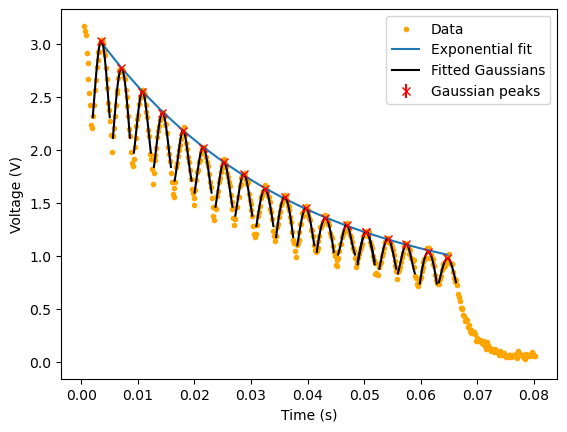

In [7]:
Filepath="C:/Users/ADMIN/Desktop/Latex/Logbook/Images/24.02.26/glyt2off1.bin"
Filepath="C:/Users/ADMIN/Desktop/Latex/Logbook/Images/03.03.26/t2lmo0.csv"
#x,y=RigolBinaryExtract(Filepath)
#identify the peaks of the data
#x,y=x[0][500:],(y[0][500:])/2
#y_err=np.zeros(len(y))+0.01
df=pd.read_csv(Filepath)
print(df)
x=df['Time(s)'][500:]
y=df['CH1V'][500:]
x=np.array(x)
y=np.array(y)
y_err=np.zeros(len(y))+0.01
print(y[0])
indeces=FindPeaks(x,y)
print(indeces)
indeces=[0, 20, 42,64, 86, 110, 132, 155, 178, 200, 222, 245, 266, 290, 310, 313, 335, 355, 381, 403]
#fit gaussians around the peaks
fittedx,fittedy,fittedparam,fittedy_err=fittopeaks(indeces[1:],x,y,y_err,width=8)
#plot the raw data, and the fitted peaks
plt.scatter(x,y,color='orange',label='Data',marker='.')
plt.errorbar(fittedx,fittedy,fittedy_err, label="Gaussian peaks",fmt='rx')
#fit an exponential to the fitted peaks
fitpeaks=scipy.optimize.curve_fit(exponential,fittedx,fittedy,sigma=fittedy_err)
#calcultes what the fit looks like
yfit=exponential(np.array(fittedx),*fitpeaks[0])
#plot the exponential fit, and give plot labels
plt.plot(np.array(fittedx),yfit,label='Exponential fit')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
#plots the fitted gaussians found earlier.
for param in fittedparam:
    mean=param[2]
    width=0.0015
    xgauss=np.linspace(mean-width,mean+width,100)
    plt.plot(xgauss,gauss(xgauss,*param),color='black')
plt.plot(0.08,0,color='black',label='Fitted Gaussians')
plt.legend()
residuals=fittedy-yfit
pulls=residuals/fittedy_err
chisquare=np.sum(pulls**2)
dof=len(pulls)-len(fitpeaks[0])
Tau=1/(-1*fitpeaks[0][0])
Tau_err=(fitpeaks[1][0][0]**0.5)*(Tau**2)
print('the calculated T2 was '+str(Tau)+' +/- '+str(Tau_err))

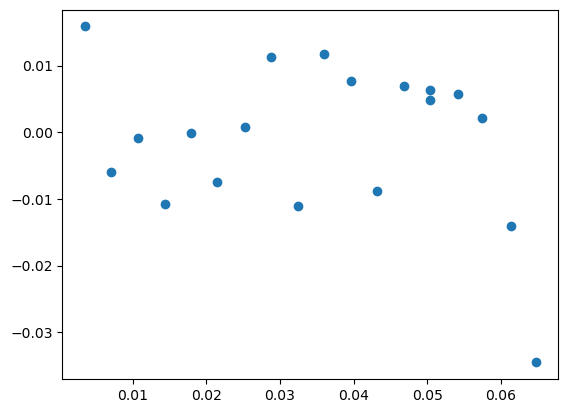

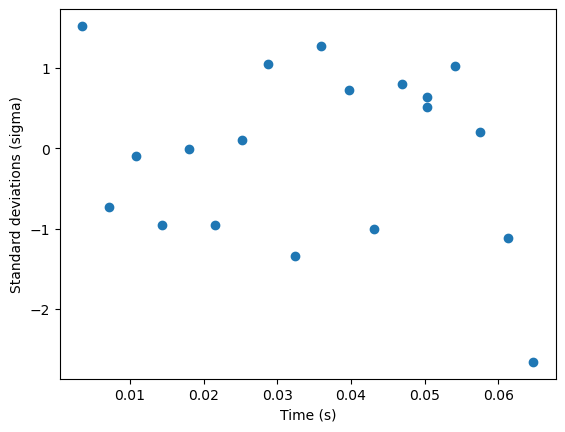

1.3385381950131536 21.416611120210458
pvalue=0.16304667882336876


In [8]:
plt.figure()
plt.scatter(fittedx,residuals)
plt.show()
plt.figure()
plt.xlabel('Time (s)')
plt.ylabel('Standard deviations (sigma)')
plt.scatter(fittedx,pulls)
plt.show()
print(chisquare/dof,chisquare)
chi2 = stats.chi2
p_value = chi2.sf(chisquare, dof)
print('pvalue='+str(p_value))